# Milestone 1: Threat Index Planning and Initial Development

## 1. Preliminary Thoughts 

We are thinking of focusing on a perfect beach day index. Possible variables include temperature, UV, tide, water temperature, precipitation/storms, dew point, wind, water conditions, and sea levels. We are thinking about focusing on the Eastern coast of CONUS and the gulf since it would have the most variability with the seasons. This hazard is interesting to explore because it can vary for the beaches spread across the country, as different conditions might be optimal at different times of the years. It can also show the frequency in dangerous conditions at the beach, and help to find the best time to go. By focusing on these variables, it can help people to make a decicision that could impact their life. It can quanitfy potentially dangerous factors, such as rip currents, extreme heat, and wind blowing heavy objects.

In [1]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask

run= pd.Timestamp("2025-07-01-12")  

In [8]:
H = Herbie(run, model="gfs", fxx=12, save_dir='./data/', overwrite=True, source='ncei_analysis')

✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2025-Jul-01 12:00 UTC F12 ┊ GRIB2 @ aws ┊ IDX @ aws


In [9]:
table= H.inventory()

In [10]:
table.variable.unique()

array(['PRMSL', 'CLMR', 'ICMR', 'RWMR', 'SNMR', 'GRLE', 'REFD', 'REFC',
       'VIS', 'UGRD', 'VGRD', 'VRATE', 'GUST', 'HGT', 'TMP', 'RH', 'SPFH',
       'VVEL', 'DZDT', 'ABSV', 'O3MR', 'TCDC', 'HINDEX', 'MSLET', 'PRES',
       'TSOIL', 'SOILW', 'SOILL', 'CNWAT', 'WEASD', 'SNOD', 'PEVPR',
       'ICETK', 'DPT', 'APTMP', 'TMAX', 'TMIN', 'ICEG', 'CPOFP', 'CPRAT',
       'PRATE', 'APCP', 'ACPCP', 'WATR', 'CSNOW', 'CICEP', 'CFRZR',
       'CRAIN', 'LHTFL', 'SHTFL', 'GFLUX', 'UFLX', 'VFLX', 'SFCR',
       'FRICV', 'U-GWD', 'V-GWD', 'VEG', 'SOTYP', 'WILT', 'FLDCP',
       'SUNSD', 'LFTX', 'CAPE', 'CIN', 'PWAT', 'CWAT', 'TOZNE', 'LCDC',
       'MCDC', 'HCDC', 'CWORK', 'DSWRF', 'DLWRF', 'USWRF', 'ULWRF',
       'HLCY', 'USTM', 'VSTM', 'ICAHT', 'VWSH', '4LFTX', 'HPBL', 'POT',
       'PLPL', 'LAND', 'ICEC', 'ALBDO', 'ICETMP'], dtype=object)

In [19]:
ss = r":((DPT|TMP):(2 m above ground))|(TCDC:entire atmosphere:\d+\s)|(APCP:surface:0)" 
ss2 = r"((UGRD|VGRD):(10 m above ground))"

H.inventory(ss)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this,FILE
0,580,418121091,418640029.0,418121091-418640029,2025-07-01 12:00:00,2025-07-01 12:00:00,TMP,2 m above ground,anl,:TMP:2 m above ground:anl,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
1,582,419864841,420399828.0,419864841-420399828,2025-07-01 12:00:00,2025-07-01 12:00:00,DPT,2 m above ground,anl,:DPT:2 m above ground:anl,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
2,581,425356711,425875457.0,425356711-425875457,2025-07-01 12:00:00,2025-07-01 18:00:00,TMP,2 m above ground,6 hour fcst,:TMP:2 m above ground:6 hour fcst,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
3,583,427100745,427632895.0,427100745-427632895,2025-07-01 12:00:00,2025-07-01 18:00:00,DPT,2 m above ground,6 hour fcst,:DPT:2 m above ground:6 hour fcst,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
4,596,435272446,435653746.0,435272446-435653746,2025-07-01 12:00:00,2025-07-01 18:00:00,APCP,surface,0-6 hour acc fcst,:APCP:surface:0-6 hour acc fcst,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
...,...,...,...,...,...,...,...,...,...,...,...
158,636,443504473,444316952.0,443504473-444316952,2025-07-01 12:00:00,2025-07-11 06:00:00,TCDC,entire atmosphere,234 hour fcst,:TCDC:entire atmosphere:234 hour fcst,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
159,581,413555846,414073195.0,413555846-414073195,2025-07-01 12:00:00,2025-07-11 12:00:00,TMP,2 m above ground,240 hour fcst,:TMP:2 m above ground:240 hour fcst,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
160,583,415301891,415836167.0,415301891-415836167,2025-07-01 12:00:00,2025-07-11 12:00:00,DPT,2 m above ground,240 hour fcst,:DPT:2 m above ground:240 hour fcst,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....
161,597,424089570,424943237.0,424089570-424943237,2025-07-01 12:00:00,2025-07-11 12:00:00,APCP,surface,0-10 day acc fcst,:APCP:surface:0-10 day acc fcst,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs....


In [21]:
H = FastHerbie([run], model="gfs", fxx=np.arange(0,246,6).tolist(), save_dir='./data/', overwrite=True)

In [22]:
fp = H.download(ss)
fp

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

[PosixPath('data/gfs/20250701/subset_2aefcb50__gfs.t12z.pgrb2.0p25.f000'),
 PosixPath('data/gfs/20250701/subset_2ab2342c__gfs.t12z.pgrb2.0p25.f006'),
 PosixPath('data/gfs/20250701/subset_2a1295bd__gfs.t12z.pgrb2.0p25.f012'),
 PosixPath('data/gfs/20250701/subset_2a4395bd__gfs.t12z.pgrb2.0p25.f060'),
 PosixPath('data/gfs/20250701/subset_2a8995bd__gfs.t12z.pgrb2.0p25.f018'),
 PosixPath('data/gfs/20250701/subset_2a0e95bd__gfs.t12z.pgrb2.0p25.f036'),
 PosixPath('data/gfs/20250701/subset_2a2695bd__gfs.t12z.pgrb2.0p25.f090'),
 PosixPath('data/gfs/20250701/subset_2a3795bd__gfs.t12z.pgrb2.0p25.f102'),
 PosixPath('data/gfs/20250701/subset_2afb95bd__gfs.t12z.pgrb2.0p25.f108'),
 PosixPath('data/gfs/20250701/subset_2ae795bd__gfs.t12z.pgrb2.0p25.f042'),
 PosixPath('data/gfs/20250701/subset_2a3295bd__gfs.t12z.pgrb2.0p25.f066'),
 PosixPath('data/gfs/20250701/subset_2a0795bd__gfs.t12z.pgrb2.0p25.f096'),
 PosixPath('data/gfs/20250701/subset_2a0595bd__gfs.t12z.pgrb2.0p25.f084'),
 PosixPath('data/gfs/2025

In [24]:
fp2= H.download(ss2)
fp2

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

[PosixPath('data/gfs/20250701/subset_2aefaa7d__gfs.t12z.pgrb2.0p25.f000'),
 PosixPath('data/gfs/20250701/subset_2a0e88d0__gfs.t12z.pgrb2.0p25.f036'),
 PosixPath('data/gfs/20250701/subset_2a8988d0__gfs.t12z.pgrb2.0p25.f018'),
 PosixPath('data/gfs/20250701/subset_2a1c88d0__gfs.t12z.pgrb2.0p25.f048'),
 PosixPath('data/gfs/20250701/subset_2a1288d0__gfs.t12z.pgrb2.0p25.f012'),
 PosixPath('data/gfs/20250701/subset_2a7888d0__gfs.t12z.pgrb2.0p25.f054'),
 PosixPath('data/gfs/20250701/subset_2a5e88d0__gfs.t12z.pgrb2.0p25.f078'),
 PosixPath('data/gfs/20250701/subset_2a0588d0__gfs.t12z.pgrb2.0p25.f084'),
 PosixPath('data/gfs/20250701/subset_2aca88d0__gfs.t12z.pgrb2.0p25.f114'),
 PosixPath('data/gfs/20250701/subset_2a6088d0__gfs.t12z.pgrb2.0p25.f030'),
 PosixPath('data/gfs/20250701/subset_2a0788d0__gfs.t12z.pgrb2.0p25.f096'),
 PosixPath('data/gfs/20250701/subset_2ae788d0__gfs.t12z.pgrb2.0p25.f042'),
 PosixPath('data/gfs/20250701/subset_2a0e88d0__gfs.t12z.pgrb2.0p25.f024'),
 PosixPath('data/gfs/2025

In [25]:
ds = xr.open_mfdataset(fp, combine='nested', concat_dim='valid_time', engine='cfgrib')
ds

/tmp/ipykernel_1127353/3840112195.py:1: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds = xr.open_mfdataset(fp, combine='nested', concat_dim='valid_time', engine='cfgrib')
/tmp/ipykernel_1127353/3840112195.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(fp, combine='nested', concat_dim='valid_tim

<xarray.Dataset> Size: 681MB
Dimensions:            (valid_time: 41, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 328B 2025-07-01T12:00:00 ....
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
    time               datetime64[ns] 8B 2025-07-01T12:00:00
    step               (valid_time) timedelta64[ns] 328B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
    atmosphere         float64 8B 0.0
Data variables:
    t2m                (valid_time, latitude, longitude) float32 170MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    d2m                (valid_time, latitude, longitude) float32 170MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tp                 (valid_time, latitude, longitude) float32 170MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tcc                (valid_time, latitude, longitude) float32 170MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-23T16:50 GRIB to CDM+CF via cfgrib-0.9.1...

In [26]:
ds2 = xr.open_mfdataset(fp2, combine='nested', concat_dim='valid_time', engine='cfgrib')
ds2

/tmp/ipykernel_1127353/3188299145.py:1: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds2 = xr.open_mfdataset(fp2, combine='nested', concat_dim='valid_time', engine='cfgrib')


<xarray.Dataset> Size: 341MB
Dimensions:            (valid_time: 41, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 328B 2025-07-01T12:00:00 ....
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
    time               datetime64[ns] 8B 2025-07-01T12:00:00
    step               (valid_time) timedelta64[ns] 328B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 10.0
Data variables:
    u10                (valid_time, latitude, longitude) float32 170MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    v10                (valid_time, latitude, longitude) float32 170MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-23T16:50 GRIB to CDM+CF via cfgrib-0.9.1...

In [30]:
ds3= xr.merge([ds,ds2], compat='override')
ds3

/tmp/ipykernel_1127353/1016917512.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  ds3= xr.merge([ds,ds2], compat='override')


<xarray.Dataset> Size: 1GB
Dimensions:            (latitude: 721, longitude: 1440, valid_time: 41)
Coordinates:
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
  * valid_time         (valid_time) datetime64[ns] 328B 2025-07-01T12:00:00 ....
    time               datetime64[ns] 8B 2025-07-01T12:00:00
    step               (valid_time) timedelta64[ns] 328B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
    atmosphere         float64 8B 0.0
Data variables:
    t2m                (valid_time, latitude, longitude) float32 170MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    d2m                (valid_time, latitude, longitude) float32 170MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tp                 (valid_time, latitude, longitude) float32 170MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tcc                (valid_time, latitude, longitude) float32 170MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    u10                (valid_time, latitude, longitude) float32 170MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    v10                (valid_time, latitude, longitude) float32 170MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-23T16:50 GRIB to CDM+CF via cfgrib-0.9.1...

In [31]:
ds4 = ds3.sel(latitude=slice(50,25), longitude=slice(260,300))
ds4

<xarray.Dataset> Size: 16MB
Dimensions:            (latitude: 101, longitude: 161, valid_time: 41)
Coordinates:
  * latitude           (latitude) float64 808B 50.0 49.75 49.5 ... 25.25 25.0
  * longitude          (longitude) float64 1kB 260.0 260.2 260.5 ... 299.8 300.0
  * valid_time         (valid_time) datetime64[ns] 328B 2025-07-01T12:00:00 ....
    time               datetime64[ns] 8B 2025-07-01T12:00:00
    step               (valid_time) timedelta64[ns] 328B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
    atmosphere         float64 8B 0.0
Data variables:
    t2m                (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 101, 161), meta=np.ndarray>
    d2m                (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 101, 161), meta=np.ndarray>
    tp                 (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 101, 161), meta=np.ndarray>
    tcc                (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 101, 161), meta=np.ndarray>
    u10                (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 101, 161), meta=np.ndarray>
    v10                (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(1, 101, 161), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-23T16:50 GRIB to CDM+CF via cfgrib-0.9.1...

In [1]:
fname = f'beachday.nc'
ds4.to_netcdf(fname)

NameError: name 'ds4' is not defined

# Ground-Truth Observation Images
## Surface Map

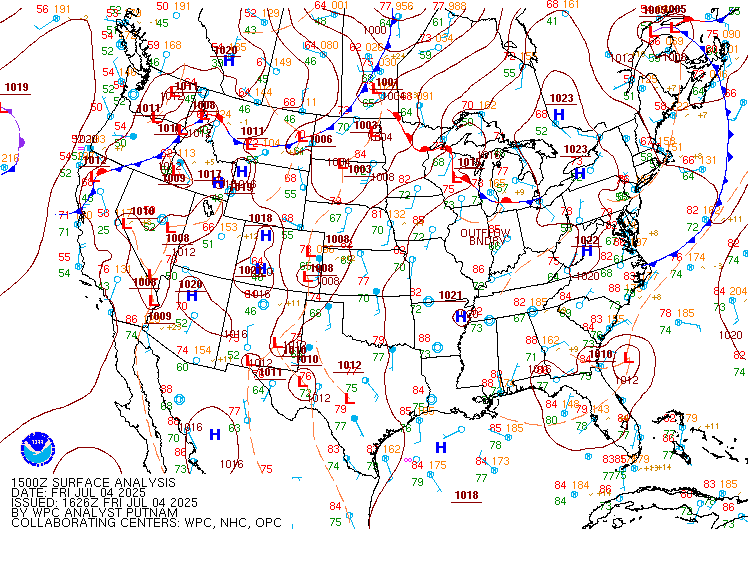

This is a surface map taken at 15 UTC on the fourth day of the dataset we chose (07/04/25). This shows the surface weather during our time frame, especially the high pressure over the East coast, which is providing good beach conditions. Our index is focused on when conditions are best to go to the beach, which is especially important on a popular beach day like July 4th.

## Radar
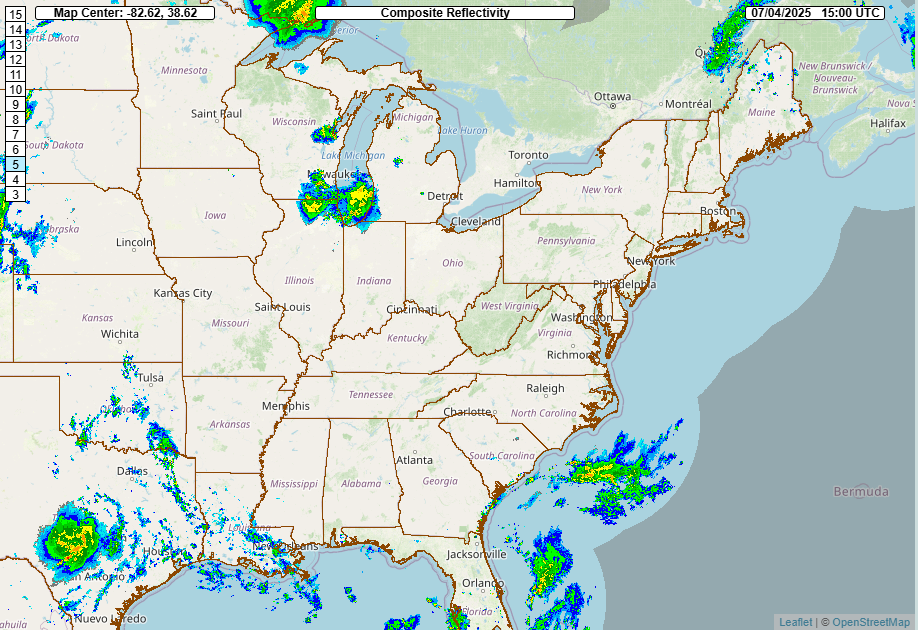

This radar image is from 15:00 UTC on 07/04/25. This is a radar image from our time frame, showing the clear conditions over the Eastern United States. 


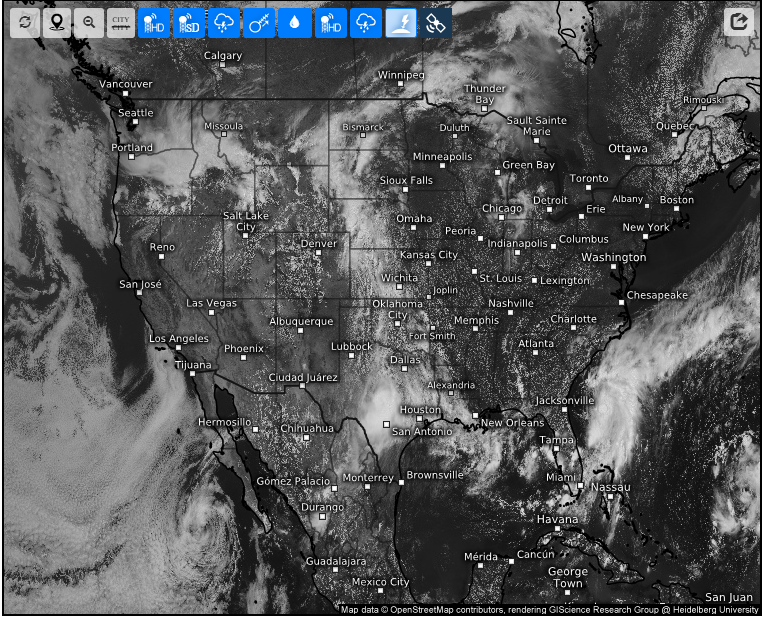

This is a satellite image from 12:00 pm on 07/04/25. This image shows the cloud cover during the time period. There is not a large amount of cloud cover, which shows that the skies were clear. Clear skies are positive for our index. 

## Index Design Brainstorm

- Our index will show the best conditions for a beach day. The index will have its highest values when the conditions are favorable to go to the beach.
- The variables for temperature and precipitation will carry the most weight for the index.
- Wind speed and dewpoint will carry the second most important weight.
- Cloud cover will carry the least weight.
- For our output range we are thinking of doing 1-10, with 10 being the highest value.
- 10 represents a 10/10 beach day.
- Variable conditions for 10 could be warm temperatures, low cloud cover, and little to no precipitation. 

In [1]:
import xarray as xr
ds = xr.open_dataset("beachday.nc")

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'h5netcdf', 'scipy', 'cfgrib', 'cfradial1', 'datamet', 'furuno', 'gamic', 'gini', 'hpl', 'iris', 'metek', 'nexradlevel2', 'odim', 'rainbow', 'uf']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

ds_time = ds.isel(valid_time=5)

def calculate_at(ds):
    # Convert Kelvin to Celsius
    T = ds['t2m'] - 273.15
    Td = ds['d2m'] - 273.15
    
    # Calculate Wind Speed (m/s)
    ws = np.sqrt(ds['u10']**2 + ds['v10']**2)
    
    # Vapor Pressure (e)
    e = 6.11 * 10**(7.5 * Td / (237.3 + Td))
    
    # Apparent Temp Formula
    at_c = T + 0.33 * e - 0.70 * ws - 4.00
    at_f = (at_c * 9/5) + 32
    return at_f

at_data = calculate_at(ds_time)



In [18]:
def base_map():
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)
    return fig, ax

Text(1.0, 1.0, 'Init: 12Z Tue Jul 01 2025\n Valid: 18Z Wed Jul 02 2025')

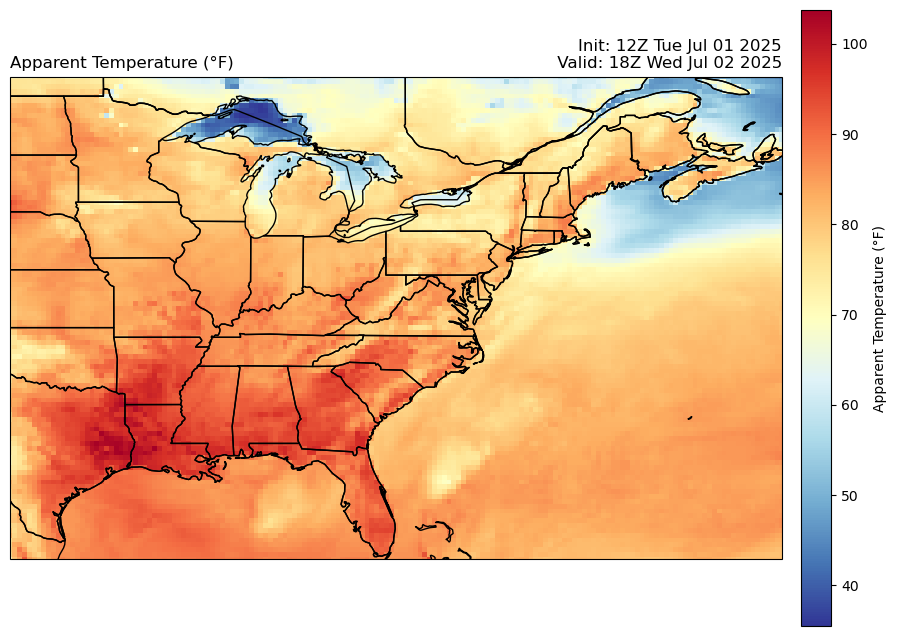

In [20]:
fig, ax = base_map()

im = ax.pcolormesh(ds_time.longitude, ds_time.latitude, at_data, 
                   transform=ccrs.PlateCarree(), 
                   cmap='RdYlBu_r')

cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, aspect=20)
cb.set_label('Apparent Temperature (°F)')

init_time = pd.to_datetime(ds.valid_time.values[0]).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.valid_time.values).strftime('%HZ %a %b %d %Y')
ax.set_title('Apparent Temperature (°F)', loc='left', fontsize=12)
ax.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=12)